## 1. Setup & Installation

In [57]:
# Install required packages
!pip install -q statsmodels scikit-learn pandas numpy matplotlib seaborn
!pip install -q ngboost ruptures
!pip install -q lion-pytorch  # Lion optimizer
!pip install -q pmdarima  # For auto_arima

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [58]:
# Install lion optimizer
!pip install -q lion-pytorch


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time series
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Advanced models
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import MLE

# Structural breaks
import ruptures as rpt

# PyTorch for custom losses and Lion optimizer
import torch
import torch.nn as nn
import torch.nn.functional as F
try:
    from lion_pytorch import Lion
    LION_AVAILABLE = True
except ImportError:
    LION_AVAILABLE = False
    print("Lion optimizer not available. Will use AdamW instead.")

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("All packages imported successfully!")

All packages imported successfully!


## 2. Data Loading & Preprocessing

In [60]:
# Load data
train_df = pd.read_csv('Inflation_features.csv', index_col=0, parse_dates=True)
test_df = pd.read_csv('Inflation_test.csv', index_col=0, parse_dates=True)

print(f'Train: {train_df.shape[0]} rows, {train_df.index.min().date()} to {train_df.index.max().date()}')
print(f'Test:  {test_df.shape[0]} rows, {test_df.index.min().date()} to {test_df.index.max().date()}')
print(f'\nColumns ({train_df.shape[1]}): {list(train_df.columns)}')

# Combine datasets
full_df = pd.concat([train_df, test_df]).sort_index()
full_df = full_df[~full_df.index.duplicated(keep='first')]
full_df['year_month'] = full_df.index.to_period('M')

print(f'\nFull dataset: {full_df.shape[0]} rows, {full_df.index.min().date()} to {full_df.index.max().date()}')
print(f'CPI range: {full_df["CPI"].min():.1f} - {full_df["CPI"].max():.1f}')

display(train_df.head())

Train: 956 rows, 2005-01-07 to 2023-04-28
Test:  151 rows, 2023-05-05 to 2026-03-20

Columns (19): ['Oil_Price', 'Gasoline_Price', 'Natural_Gas', 'Treasury_10Y', 'Treasury_2Y', 'Yield_Spread', 'VIX', 'Corporate_Spread', 'CPI', 'Wheat_Price', 'Copper_Price', 'PPI', 'Import_Price_Index', 'Unemployment_Rate', 'Retail_Sales', 'Industrial_Production', 'Fed_Funds_Rate', 'Housing_Starts', 'Home_Prices']

Full dataset: 1107 rows, 2005-01-07 to 2026-03-20
CPI range: 191.6 - 327.5


,Oil_Price,Gasoline_Price,Natural_Gas,Treasury_10Y,Treasury_2Y,Yield_Spread,VIX,Corporate_Spread,CPI,Wheat_Price,Copper_Price,PPI,Import_Price_Index,Unemployment_Rate,Retail_Sales,Industrial_Production,Fed_Funds_Rate,Housing_Starts,Home_Prices
2005-01-07,44.072,1.778,5.738,4.278,3.180,1.098,13.844,1.842,191.6,122.778962,3168.1,150.9,104.6,5.3,321272.0,95.8801,2.28,2144.0,160.130
2005-01-14,46.790,1.793,6.114,4.246,3.228,1.018,12.850,1.806,191.6,122.778962,3168.1,150.9,104.6,5.3,321272.0,95.8801,2.28,2144.0,160.130
2005-01-21,47.960,1.819,6.406,4.194,3.226,0.968,13.254,1.782,191.6,122.778962,3168.1,150.9,104.6,5.3,321272.0,95.8801,2.28,2144.0,160.130
2005-01-28,48.558,1.853,6.404,4.186,3.246,0.940,13.726,1.762,191.6,122.778962,3168.1,150.9,104.6,5.3,321272.0,95.8801,2.28,2144.0,160.130
2005-02-04,46.970,1.911,6.248,4.142,3.306,0.836,11.902,1.722,192.4,123.129961,3247.1,151.6,105.5,5.4,325308.0,96.5761,2.50,2207.0,161.925


## 3. Variable Frequency Classification

In [61]:
def classify_frequency(df, col):
    """Check if variable changes every week or stays constant within months."""
    vals = df[col].dropna()
    monthly_groups = vals.groupby(vals.index.to_period('M'))
    avg_unique_per_month = monthly_groups.nunique().mean()
    return 'weekly' if avg_unique_per_month > 1.5 else 'monthly'

freq_map = {}
for col in train_df.columns:
    if col == 'CPI':
        freq_map[col] = 'target'
    else:
        freq_map[col] = classify_frequency(train_df, col)

weekly_vars = [k for k, v in freq_map.items() if v == 'weekly']
monthly_vars = [k for k, v in freq_map.items() if v == 'monthly']

print(f'Weekly variables ({len(weekly_vars)}):  {weekly_vars}')
print(f'Monthly variables ({len(monthly_vars)}): {monthly_vars}')
print(f'Target: CPI')

Weekly variables (8):  ['Oil_Price', 'Gasoline_Price', 'Natural_Gas', 'Treasury_10Y', 'Treasury_2Y', 'Yield_Spread', 'VIX', 'Corporate_Spread']
Monthly variables (10): ['Wheat_Price', 'Copper_Price', 'PPI', 'Import_Price_Index', 'Unemployment_Rate', 'Retail_Sales', 'Industrial_Production', 'Fed_Funds_Rate', 'Housing_Starts', 'Home_Prices']
Target: CPI


## 4. Structural Break Detection (Ruptures - PELT)

Detect regime changes in the CPI time series using the PELT (Pruned Exact Linear Time) algorithm.


Detected 7 structural breaks in CPI series:
  Break 1: 2007-09-07 (index 140)
  Break 2: 2011-02-18 (index 320)
  Break 3: 2013-11-29 (index 465)
  Break 4: 2017-12-08 (index 675)
  Break 5: 2021-04-16 (index 850)
  Break 6: 2022-05-06 (index 905)
  Break 7: 2024-01-26 (index 995)


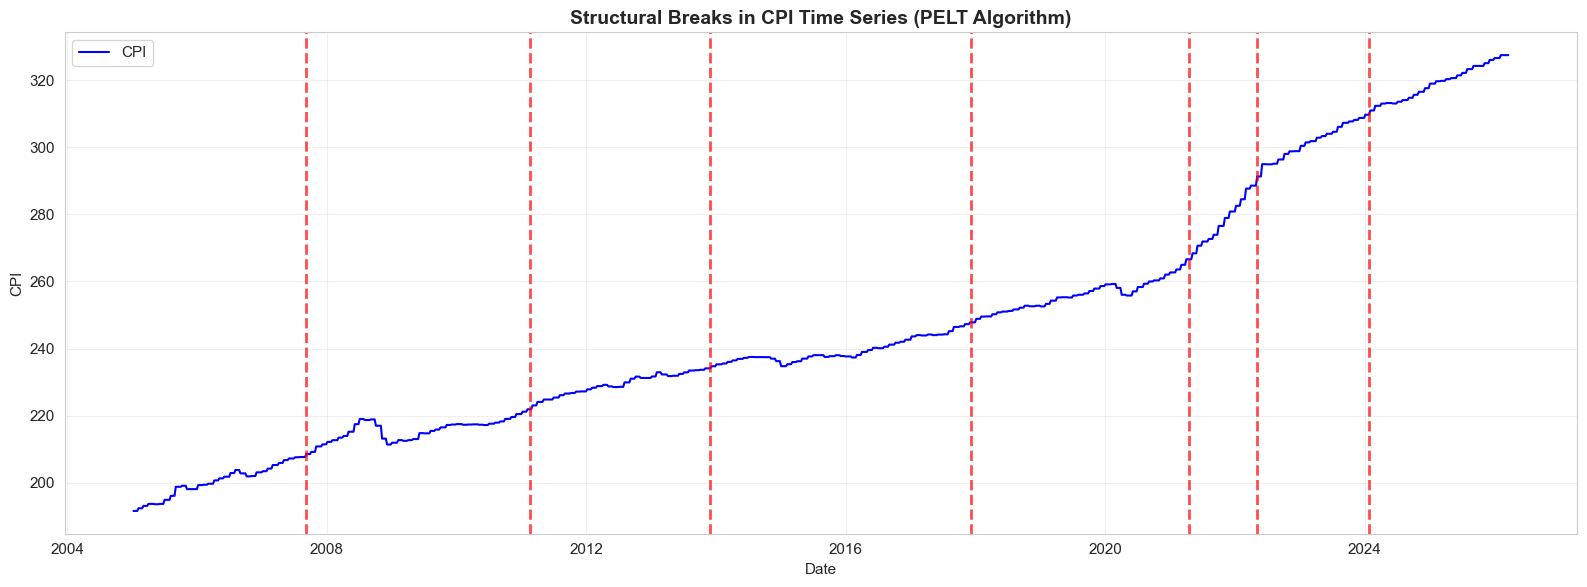


Regime distribution:
regime
0    139
1    180
2    145
3    210
4    175
5     55
6     90
7    113
Name: count, dtype: int64


In [62]:
# Prepare CPI series for structural break detection
cpi_series = full_df['CPI'].dropna().values.reshape(-1, 1)
cpi_dates = full_df['CPI'].dropna().index

# PELT algorithm for changepoint detection
algo = rpt.Pelt(model="rbf", min_size=20, jump=5).fit(cpi_series)
breakpoints = algo.predict(pen=10)

print(f"\nDetected {len(breakpoints)-1} structural breaks in CPI series:")
for i, bp in enumerate(breakpoints[:-1]):
    date = cpi_dates[bp-1]
    print(f"  Break {i+1}: {date.date()} (index {bp})")

# Visualize
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(cpi_dates, cpi_series, 'b-', linewidth=1.5, label='CPI')
for bp in breakpoints[:-1]:
    ax.axvline(cpi_dates[bp-1], color='red', linestyle='--', alpha=0.7, linewidth=2)
ax.set_title('Structural Breaks in CPI Time Series (PELT Algorithm)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('CPI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create regime indicator
full_df['regime'] = 0
for i, bp in enumerate(breakpoints[:-1]):
    full_df.loc[full_df.index >= cpi_dates[bp-1], 'regime'] = i + 1

print(f"\nRegime distribution:")
print(full_df['regime'].value_counts().sort_index())

## 5. Feature Engineering with STL Decomposition

Decompose key variables into **Trend**, **Seasonal**, and **Residual** components using STL (Seasonal and Trend decomposition using Loess).

  ✓ STL decomposition completed for CPI
  ✓ STL decomposition completed for Oil_Price
  ✓ STL decomposition completed for Gasoline_Price
  ✓ STL decomposition completed for VIX
  ✓ STL decomposition completed for Treasury_10Y

STL Decomposition completed. New features created:
  15 STL component features


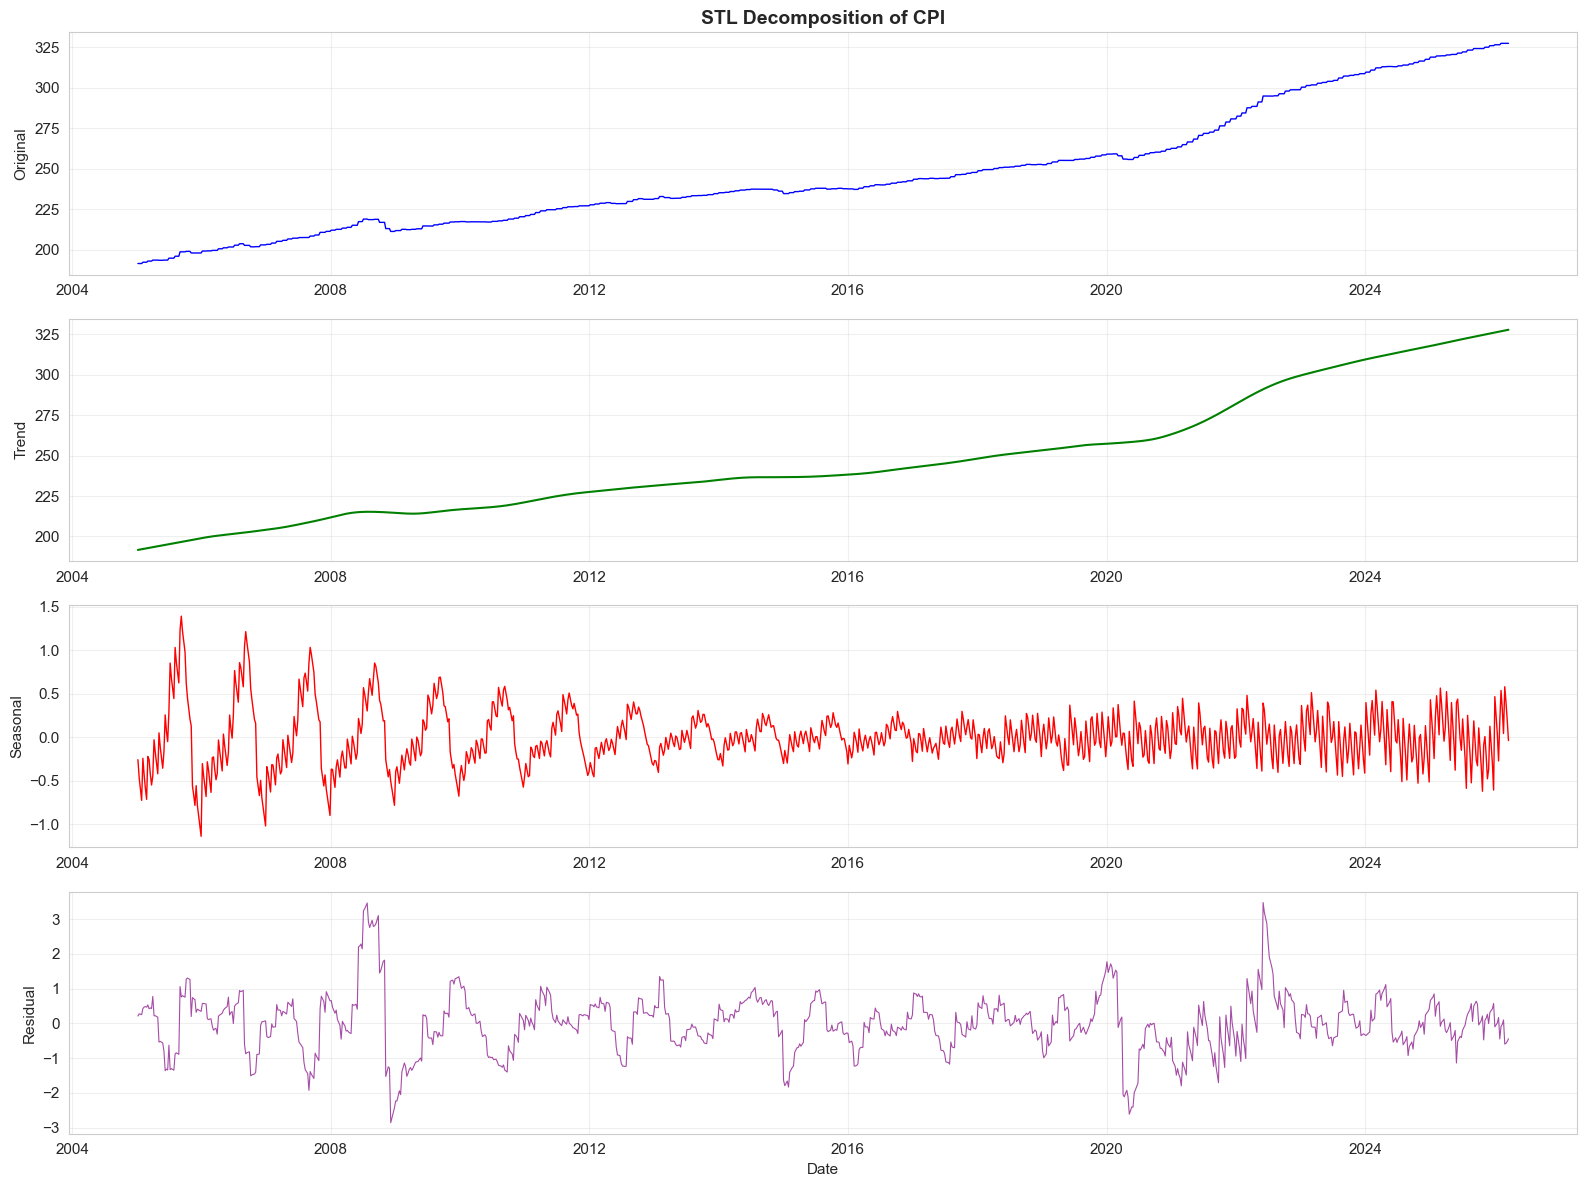

In [63]:
# Select key variables for STL decomposition
stl_vars = ['CPI', 'Oil_Price', 'Gasoline_Price', 'VIX', 'Treasury_10Y']
stl_period = 52  # Weekly data, ~52 weeks in a year

# Apply STL decomposition
for var in stl_vars:
    if var in full_df.columns:
        series = full_df[var].dropna()
        if len(series) > stl_period * 2:
            try:
                stl = STL(series, period=stl_period, seasonal=13)
                result = stl.fit()
                
                # Add components as features
                full_df[f'{var}_trend'] = result.trend
                full_df[f'{var}_seasonal'] = result.seasonal
                full_df[f'{var}_resid'] = result.resid
                print(f"  ✓ STL decomposition completed for {var}")
            except Exception as e:
                print(f"  ✗ STL decomposition failed for {var}: {str(e)[:50]}")

print("\nSTL Decomposition completed. New features created:")
stl_features = [col for col in full_df.columns if any(x in col for x in ['_trend', '_seasonal', '_resid'])]
print(f"  {len(stl_features)} STL component features")

# Visualize STL decomposition for CPI
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
cpi_clean = full_df['CPI'].dropna()
stl_cpi = STL(cpi_clean, period=stl_period, seasonal=13).fit()

axes[0].plot(cpi_clean.index, cpi_clean.values, 'b-', linewidth=1)
axes[0].set_ylabel('Original')
axes[0].set_title('STL Decomposition of CPI', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(stl_cpi.trend.index, stl_cpi.trend.values, 'g-', linewidth=1.5)
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

axes[2].plot(stl_cpi.seasonal.index, stl_cpi.seasonal.values, 'r-', linewidth=1)
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

axes[3].plot(stl_cpi.resid.index, stl_cpi.resid.values, 'purple', linewidth=0.8, alpha=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Causal Discovery with Granger Causality

Test whether past values of predictor variables help predict CPI beyond CPI's own lags.


Granger Causality Tests (does X Granger-cause CPI?):
Oil_Price                 | Best lag: 4 | p-value: 0.0000 ***
Gasoline_Price            | Best lag: 2 | p-value: 0.0000 ***
Natural_Gas               | Best lag: 1 | p-value: 0.0274 **
Treasury_10Y              | Best lag: 3 | p-value: 0.0000 ***
Treasury_2Y               | Best lag: 3 | p-value: 0.0000 ***
Yield_Spread              | Best lag: 4 | p-value: 0.1456 

Variables that Granger-cause CPI (p < 0.05): ['Oil_Price', 'Gasoline_Price', 'Natural_Gas', 'Treasury_10Y', 'Treasury_2Y']


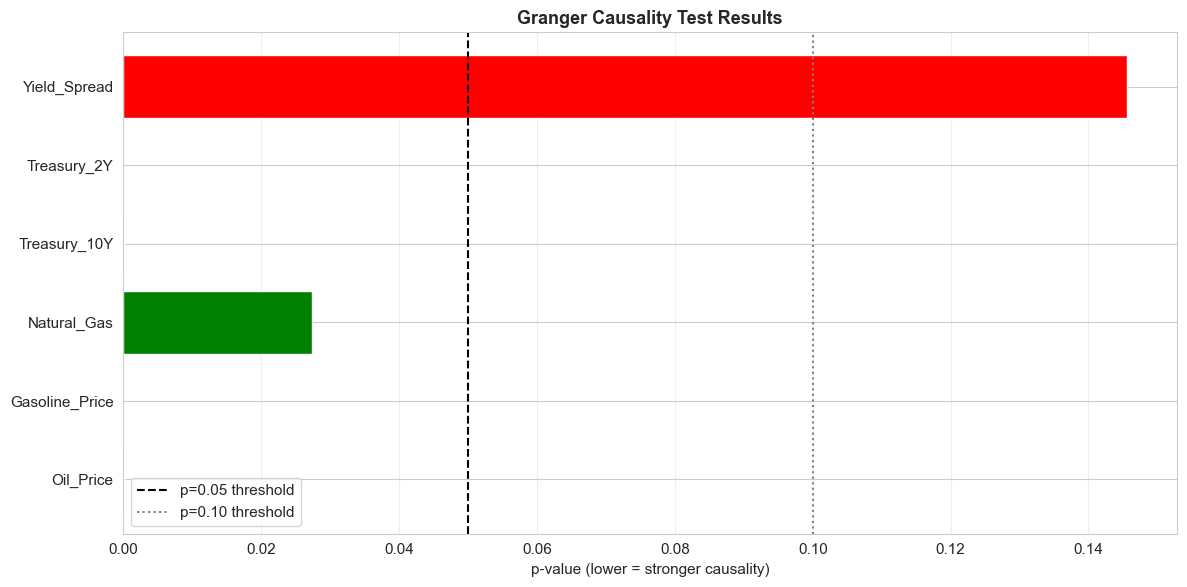

In [64]:
# Prepare data for Granger causality
granger_vars = weekly_vars[:6]  # Test top 6 weekly variables
max_lag = 4

granger_results = {}

print("\nGranger Causality Tests (does X Granger-cause CPI?):")
print("="*70)

for var in granger_vars:
    try:
        # Prepare bivariate data
        data = full_df[[var, 'CPI']].dropna()
        
        # Run Granger causality test
        gc_result = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        
        # Extract F-test p-values
        p_values = [gc_result[i+1][0]['ssr_ftest'][1] for i in range(max_lag)]
        min_p = min(p_values)
        best_lag = p_values.index(min_p) + 1
        
        granger_results[var] = {
            'p_values': p_values,
            'min_p': min_p,
            'best_lag': best_lag,
            'significant': min_p < 0.05
        }
        
        sig_marker = "***" if min_p < 0.01 else "**" if min_p < 0.05 else "*" if min_p < 0.10 else ""
        print(f"{var:25s} | Best lag: {best_lag} | p-value: {min_p:.4f} {sig_marker}")
        
    except Exception as e:
        print(f"{var:25s} | Error: {str(e)[:50]}")

# Significant Granger causes
significant_causes = [var for var, res in granger_results.items() if res['significant']]
print(f"\nVariables that Granger-cause CPI (p < 0.05): {significant_causes}")

# Visualize Granger causality results
if granger_results:
    fig, ax = plt.subplots(figsize=(12, 6))
    vars_list = list(granger_results.keys())
    p_vals = [granger_results[v]['min_p'] for v in vars_list]
    colors = ['green' if p < 0.05 else 'orange' if p < 0.10 else 'red' for p in p_vals]
    
    ax.barh(vars_list, p_vals, color=colors, edgecolor='white')
    ax.axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='p=0.05 threshold')
    ax.axvline(0.10, color='gray', linestyle=':', linewidth=1.5, label='p=0.10 threshold')
    ax.set_xlabel('p-value (lower = stronger causality)')
    ax.set_title('Granger Causality Test Results', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## 7. Traditional Feature Engineering: Lag Monthly Variables

In [65]:
# Lag monthly variables by 1 month (prevent data leakage)
for col in monthly_vars:
    series = full_df.groupby('year_month')[col].first()
    lagged = series.shift(1)
    full_df[f'{col}_lag1m'] = full_df['year_month'].map(lagged)

lagged_monthly_vars = [f'{c}_lag1m' for c in monthly_vars]

# Add lagged CPI and momentum
cpi_monthly = full_df.groupby('year_month')['CPI'].first()
cpi_lag1 = cpi_monthly.shift(1)
cpi_lag2 = cpi_monthly.shift(2)

full_df['CPI_lag1m'] = full_df['year_month'].map(cpi_lag1)
full_df['CPI_lag2m'] = full_df['year_month'].map(cpi_lag2)
full_df['CPI_change'] = full_df['CPI'] - full_df['CPI_lag1m']
full_df['CPI_change_lag1m'] = full_df['CPI_lag1m'] - full_df['CPI_lag2m']

# Feature sets
feature_cols_base = weekly_vars + lagged_monthly_vars
feature_cols_enhanced = (feature_cols_base + 
                         ['CPI_lag1m', 'CPI_change_lag1m', 'regime'] +
                         [col for col in full_df.columns if '_trend' in col or '_seasonal' in col])

# Remove duplicates and ensure all features exist
feature_cols_enhanced = [c for c in feature_cols_enhanced if c in full_df.columns]
feature_cols_enhanced = list(dict.fromkeys(feature_cols_enhanced))

print(f'\nBase features: {len(feature_cols_base)}')
print(f'Enhanced features (w/ STL, regime): {len(feature_cols_enhanced)}')
print(f'\nSample enhanced features: {feature_cols_enhanced[:15]}')


Base features: 18
Enhanced features (w/ STL, regime): 31

Sample enhanced features: ['Oil_Price', 'Gasoline_Price', 'Natural_Gas', 'Treasury_10Y', 'Treasury_2Y', 'Yield_Spread', 'VIX', 'Corporate_Spread', 'Wheat_Price_lag1m', 'Copper_Price_lag1m', 'PPI_lag1m', 'Import_Price_Index_lag1m', 'Unemployment_Rate_lag1m', 'Retail_Sales_lag1m', 'Industrial_Production_lag1m']


## 8. Train/Test Split

In [66]:
# Prepare modeling dataset
all_cols = list(dict.fromkeys(['CPI', 'CPI_change', 'CPI_lag1m'] + feature_cols_enhanced))
all_cols = [c for c in all_cols if c in full_df.columns]
model_df = full_df[all_cols].dropna().copy()

# Time-based split
split_date = train_df.index.max()
train_data = model_df[model_df.index <= split_date]
test_data = model_df[model_df.index > split_date]

print(f'Train: {train_data.shape[0]} rows ({train_data.index.min().date()} to {train_data.index.max().date()})')
print(f'Test:  {test_data.shape[0]} rows ({test_data.index.min().date()} to {test_data.index.max().date()})')

# Prepare arrays
X_train = train_data[feature_cols_enhanced].values
y_train_level = train_data['CPI'].values
y_train_change = train_data['CPI_change'].values

X_test = test_data[feature_cols_enhanced].values
y_test_level = test_data['CPI'].values
y_test_change = test_data['CPI_change'].values
cpi_lag_test = test_data['CPI_lag1m'].values.ravel()

# Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nX_train shape: {X_train_s.shape}')
print(f'X_test shape: {X_test_s.shape}')

Train: 948 rows (2005-03-04 to 2023-04-28)
Test:  151 rows (2023-05-05 to 2026-03-20)

X_train shape: (948, 31)
X_test shape: (151, 31)


## 9. Custom Loss Functions

Define custom loss functions for robust predictions:
1. **Asymmetric Huber Loss**: Penalizes over-predictions more than under-predictions
2. **Quantile/Pinball Loss**: For quantile regression

In [67]:
class AsymmetricHuberLoss(nn.Module):
    """
    Asymmetric Huber Loss that penalizes over-predictions more heavily.
    
    Args:
        delta: Threshold for switching from quadratic to linear
        asymmetry: Multiplier for over-predictions (> 1.0 means penalize more)
    """
    def __init__(self, delta=1.0, asymmetry=1.5):
        super().__init__()
        self.delta = delta
        self.asymmetry = asymmetry
    
    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        
        # Standard Huber loss
        abs_error = torch.abs(error)
        quadratic = torch.clamp(abs_error, max=self.delta)
        linear = abs_error - quadratic
        loss = 0.5 * quadratic**2 + self.delta * linear
        
        # Apply asymmetry (penalize over-predictions more)
        over_pred_mask = (y_pred > y_true).float()
        loss = loss * (1 + over_pred_mask * (self.asymmetry - 1))
        
        return loss.mean()


class QuantileLoss(nn.Module):
    """
    Quantile/Pinball Loss for quantile regression.
    
    Args:
        quantile: Target quantile (0.5 for median)
    """
    def __init__(self, quantile=0.5):
        super().__init__()
        self.quantile = quantile
    
    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        loss = torch.max(
            self.quantile * error,
            (self.quantile - 1) * error
        )
        return loss.mean()


# Test the loss functions
y_true_sample = torch.tensor([100.0, 105.0, 110.0])
y_pred_over = torch.tensor([105.0, 110.0, 115.0])  # Over-predictions
y_pred_under = torch.tensor([95.0, 100.0, 105.0])  # Under-predictions

asym_loss = AsymmetricHuberLoss(delta=1.0, asymmetry=1.5)
quantile_loss = QuantileLoss(quantile=0.5)

print("\nCustom Loss Function Tests:")
print(f"Asymmetric Huber (over-predictions):  {asym_loss(y_pred_over, y_true_sample):.4f}")
print(f"Asymmetric Huber (under-predictions): {asym_loss(y_pred_under, y_true_sample):.4f}")
print(f"Quantile Loss (median):               {quantile_loss(y_pred_over, y_true_sample):.4f}")
print("\n✓ Over-predictions are penalized more heavily (higher loss)")


Custom Loss Function Tests:
Asymmetric Huber (over-predictions):  6.7500
Asymmetric Huber (under-predictions): 4.5000
Quantile Loss (median):               2.5000

✓ Over-predictions are penalized more heavily (higher loss)


## 10. Model Training: NG-Boost

Natural Gradient Boosting for probabilistic predictions with uncertainty estimates.

Training NG-Boost model...

NG-Boost Results:
  RMSE: 0.5876
  MAE:  0.4620
  R²:   0.9932
  Mean prediction uncertainty (std): 0.1088


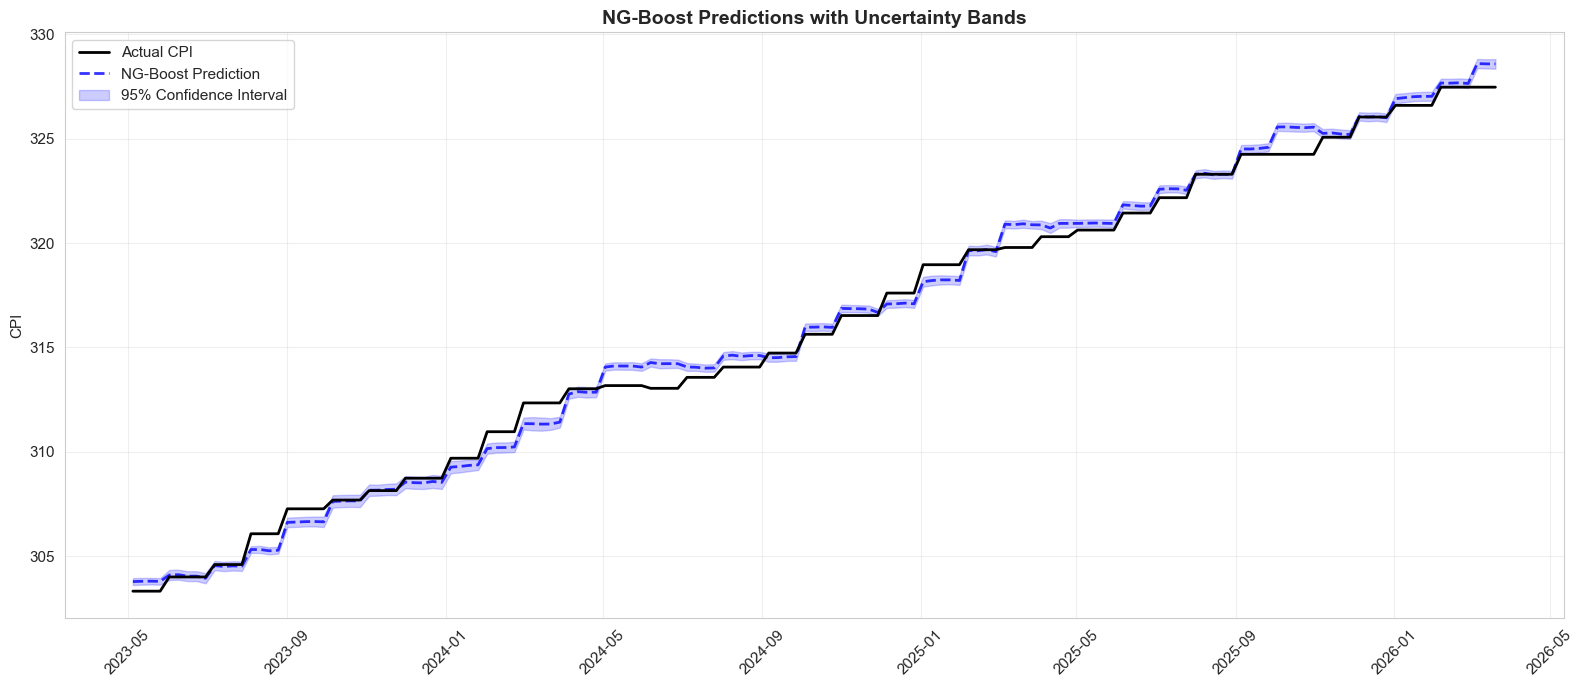

In [68]:
# Train NG-Boost for CPI change prediction
print("Training NG-Boost model...")

ngb = NGBRegressor(
    Dist=Normal,
    Score=MLE,                                    # ← removed ()
    Base=DecisionTreeRegressor(max_depth=5),
    n_estimators=500,
    learning_rate=0.01,
    minibatch_frac=0.8,
    verbose=False,
    random_state=42
)

ngb.fit(X_train_s, y_train_change)

# Predictions with uncertainty
ngb_preds = ngb.predict(X_test_s)
ngb_dist  = ngb.pred_dist(X_test_s)

# Extract mean and standard deviation
ngb_mean = ngb_dist.loc
ngb_std  = ngb_dist.scale

# Convert change predictions to level predictions
ngb_level_pred  = cpi_lag_test + ngb_mean
ngb_level_lower = cpi_lag_test + (ngb_mean - 1.96 * ngb_std)  # 95% CI lower
ngb_level_upper = cpi_lag_test + (ngb_mean + 1.96 * ngb_std)  # 95% CI upper

# Evaluate
ngb_rmse = np.sqrt(mean_squared_error(y_test_level, ngb_level_pred))
ngb_mae  = mean_absolute_error(y_test_level, ngb_level_pred)
ngb_r2   = r2_score(y_test_level, ngb_level_pred)

print(f"\nNG-Boost Results:")
print(f"  RMSE: {ngb_rmse:.4f}")
print(f"  MAE:  {ngb_mae:.4f}")
print(f"  R²:   {ngb_r2:.4f}")
print(f"  Mean prediction uncertainty (std): {ngb_std.mean():.4f}")

# Visualize predictions with uncertainty bands
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test_data.index, y_test_level, 'k-',  linewidth=2, label='Actual CPI', zorder=5)
ax.plot(test_data.index, ngb_level_pred, 'b--', linewidth=2, label='NG-Boost Prediction', alpha=0.8)
ax.fill_between(test_data.index, ngb_level_lower, ngb_level_upper,
                alpha=0.2, color='blue', label='95% Confidence Interval')
ax.set_title('NG-Boost Predictions with Uncertainty Bands', fontsize=14, fontweight='bold')
ax.set_ylabel('CPI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Quantile Regression for Prediction Intervals

Use Gradient Boosting with quantile loss to estimate prediction intervals.


Training Quantile Regression models...
  Quantile 0.05 model trained
  Quantile 0.50 model trained
  Quantile 0.95 model trained

Quantile Regression Results:
  Median RMSE: 0.5264
  Median MAE:  0.4056
  Median R²:   0.9945
  Coverage (5%-95%): 90.07% (target: 90%)
  Avg interval width: 1.3456


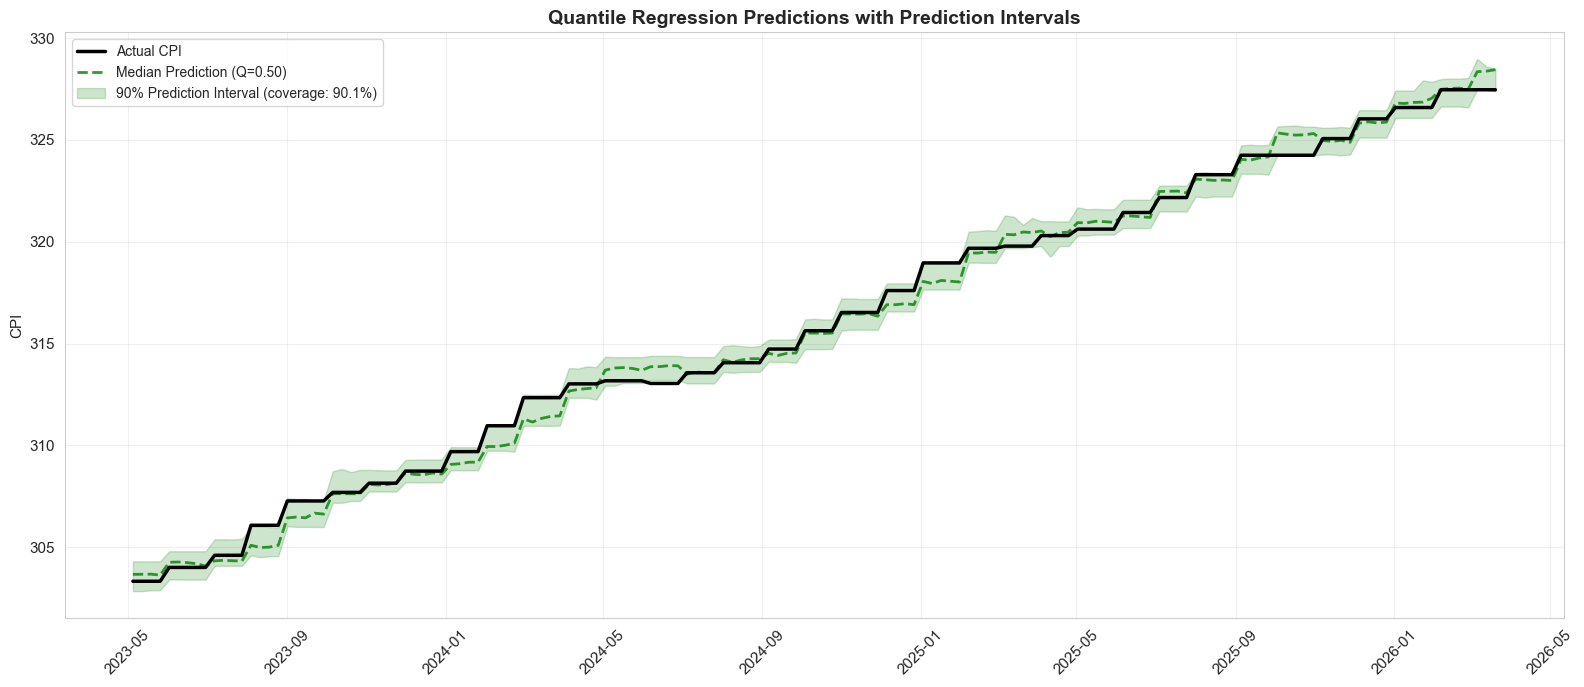

In [69]:
print("\nTraining Quantile Regression models...")

# Train models for different quantiles
quantiles = [0.05, 0.50, 0.95]  # 5th, 50th (median), 95th percentiles
quantile_models = {}
quantile_predictions = {}

for q in quantiles:
    model = GradientBoostingRegressor(
        loss='quantile',
        alpha=q,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_s, y_train_change)
    pred_change = model.predict(X_test_s)
    pred_level = cpi_lag_test + pred_change
    
    quantile_models[q] = model
    quantile_predictions[q] = pred_level
    
    print(f"  Quantile {q:.2f} model trained")

# Calculate metrics for median prediction
qr_median_rmse = np.sqrt(mean_squared_error(y_test_level, quantile_predictions[0.50]))
qr_median_mae = mean_absolute_error(y_test_level, quantile_predictions[0.50])
qr_median_r2 = r2_score(y_test_level, quantile_predictions[0.50])

# Calculate coverage (% of actual values within prediction interval)
within_interval = ((y_test_level >= quantile_predictions[0.05]) & 
                   (y_test_level <= quantile_predictions[0.95]))
coverage = within_interval.mean()
interval_width = np.mean(quantile_predictions[0.95] - quantile_predictions[0.05])

print(f"\nQuantile Regression Results:")
print(f"  Median RMSE: {qr_median_rmse:.4f}")
print(f"  Median MAE:  {qr_median_mae:.4f}")
print(f"  Median R²:   {qr_median_r2:.4f}")
print(f"  Coverage (5%-95%): {coverage:.2%} (target: 90%)")
print(f"  Avg interval width: {interval_width:.4f}")

# Visualize quantile predictions
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test_data.index, y_test_level, 'k-', linewidth=2.5, label='Actual CPI', zorder=10)
ax.plot(test_data.index, quantile_predictions[0.50], 'g--', linewidth=2, 
        label='Median Prediction (Q=0.50)', alpha=0.8)
ax.fill_between(test_data.index, 
                quantile_predictions[0.05], 
                quantile_predictions[0.95],
                alpha=0.2, color='green', 
                label=f'90% Prediction Interval (coverage: {coverage:.1%})')
ax.set_title('Quantile Regression Predictions with Prediction Intervals', fontsize=14, fontweight='bold')
ax.set_ylabel('CPI')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. LSTM with Lion Optimizer and Cosine Annealing

Train an LSTM model with advanced optimization techniques.


LSTM sequence shapes:
  X_train: torch.Size([938, 10, 31]) (samples, seq_length, features)
  X_test:  torch.Size([141, 10, 31])
  Device: cpu

Training LSTM with Lion optimizer and Cosine Annealing...
  Epoch 20/100 | Loss: 0.0365 | LR: 0.000905
  Epoch 40/100 | Loss: 0.0142 | LR: 0.000655
  Epoch 60/100 | Loss: 0.0053 | LR: 0.000346
  Epoch 80/100 | Loss: 0.0015 | LR: 0.000096
  Epoch 100/100 | Loss: 0.0009 | LR: 0.000001

LSTM Results (Lion + Cosine Annealing + Asymmetric Huber):
  RMSE: 0.6357
  MAE:  0.5441
  R²:   0.9906


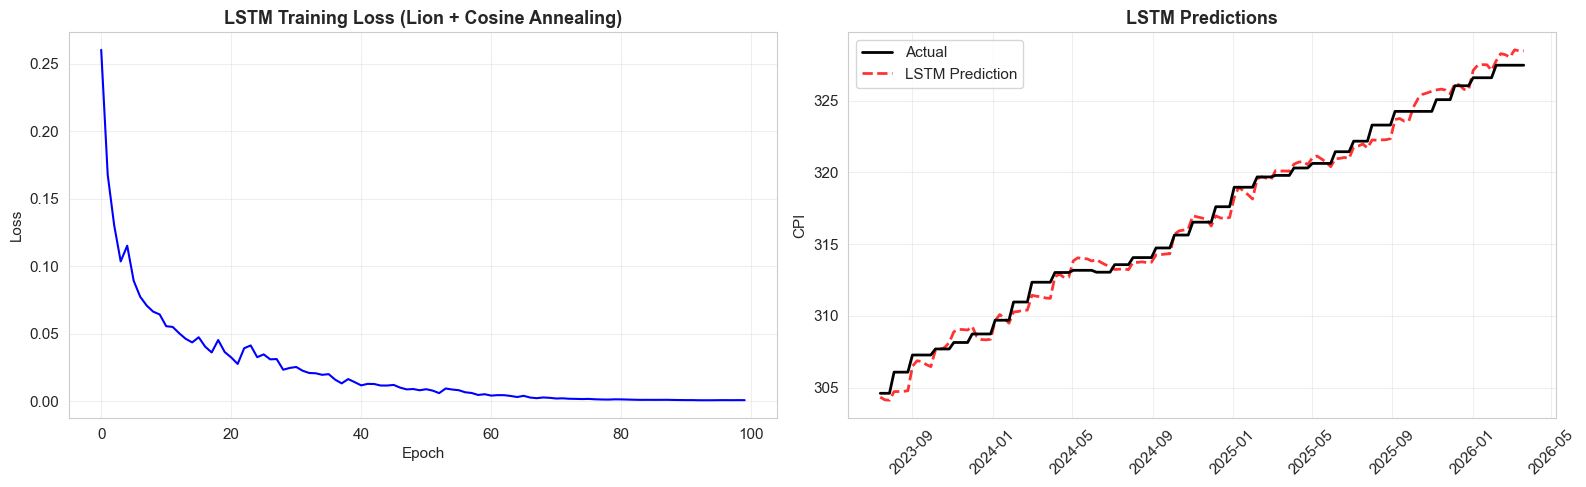

In [70]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)
        # Take the last time step
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()


# Prepare sequence data for LSTM
def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(X_train_s, y_train_change, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_s, y_test_change, seq_length)
cpi_lag_test_seq = cpi_lag_test[seq_length:]

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.FloatTensor(y_train_seq)
X_test_t = torch.FloatTensor(X_test_seq)
y_test_t = torch.FloatTensor(y_test_seq)

print(f"\nLSTM sequence shapes:")
print(f"  X_train: {X_train_t.shape} (samples, seq_length, features)")
print(f"  X_test:  {X_test_t.shape}")

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

lstm_model = LSTMModel(
    input_size=X_train_t.shape[2],
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

# Loss function and optimizer
criterion = AsymmetricHuberLoss(delta=1.0, asymmetry=1.3)

if LION_AVAILABLE:
    optimizer = Lion(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
    opt_name = "Lion"
else:
    optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
    opt_name = "AdamW"

# Cosine annealing scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=100,  # Number of epochs
    eta_min=1e-6
)

print(f"\nTraining LSTM with {opt_name} optimizer and Cosine Annealing...")

# Training loop
epochs = 100
batch_size = 32
train_losses = []

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)

for epoch in range(epochs):
    lstm_model.train()
    epoch_loss = 0
    
    # Mini-batch training
    indices = torch.randperm(len(X_train_t))
    for i in range(0, len(X_train_t), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_t[batch_idx]
        y_batch = y_train_t[batch_idx]
        
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
    
    scheduler.step()
    train_losses.append(epoch_loss / (len(X_train_t) // batch_size))
    
    if (epoch + 1) % 20 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | LR: {current_lr:.6f}")

# Evaluate
lstm_model.eval()
with torch.no_grad():
    lstm_preds_change = lstm_model(X_test_t).cpu().numpy()

lstm_preds_level = cpi_lag_test_seq + lstm_preds_change
y_test_level_seq = y_test_level[seq_length:]

lstm_rmse = np.sqrt(mean_squared_error(y_test_level_seq, lstm_preds_level))
lstm_mae = mean_absolute_error(y_test_level_seq, lstm_preds_level)
lstm_r2 = r2_score(y_test_level_seq, lstm_preds_level)

print(f"\nLSTM Results ({opt_name} + Cosine Annealing + Asymmetric Huber):")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE:  {lstm_mae:.4f}")
print(f"  R²:   {lstm_r2:.4f}")

# Plot training loss and predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses, 'b-', linewidth=1.5)
axes[0].set_title(f'LSTM Training Loss ({opt_name} + Cosine Annealing)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

test_dates = test_data.index[seq_length:]
axes[1].plot(test_dates, y_test_level_seq, 'k-', linewidth=2, label='Actual', zorder=5)
axes[1].plot(test_dates, lstm_preds_level, 'r--', linewidth=2, label='LSTM Prediction', alpha=0.8)
axes[1].set_title('LSTM Predictions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('CPI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 13. Baseline Models (Ridge, LASSO, Random Forest, etc.)

In [71]:
# Train baseline regression models
baseline_models = {
    'Ridge': Ridge(alpha=10),
    'LASSO': Lasso(alpha=0.001, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
}

baseline_results = {}

print("\nTraining baseline regression models (predicting CPI change)...")

for name, model in baseline_models.items():
    model.fit(X_train_s, y_train_change)
    preds_change = model.predict(X_test_s)
    preds_level = cpi_lag_test + preds_change
    
    rmse = np.sqrt(mean_squared_error(y_test_level, preds_level))
    mae = mean_absolute_error(y_test_level, preds_level)
    r2 = r2_score(y_test_level, preds_level)
    
    baseline_results[name] = {
        'predictions': preds_level,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }
    
    print(f"  {name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


Training baseline regression models (predicting CPI change)...
  Ridge                | RMSE: 0.7038 | MAE: 0.6014 | R²: 0.9902
  LASSO                | RMSE: 0.3823 | MAE: 0.2962 | R²: 0.9971
  ElasticNet           | RMSE: 0.6420 | MAE: 0.5445 | R²: 0.9918
  Random Forest        | RMSE: 0.7725 | MAE: 0.6333 | R²: 0.9882
  Gradient Boosting    | RMSE: 0.6435 | MAE: 0.4993 | R²: 0.9918


## 14. Time Series Models (ARIMA, ARIMAX)

In [72]:
# Prepare monthly CPI series for ARIMA
# Use the index to create year_month grouping
!pip install pmdarima
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()

train_data_copy['year_month'] = train_data_copy.index.to_period('M')
test_data_copy['year_month'] = test_data_copy.index.to_period('M')

cpi_train_monthly = train_data_copy.groupby('year_month')['CPI'].first()
cpi_test_monthly = test_data_copy.groupby('year_month')['CPI'].first()

print("\nTraining ARIMA model...")

# ARIMA (auto-select order based on AIC)
try:
    from pmdarima import auto_arima
    
    arima_model = auto_arima(
        cpi_train_monthly,
        start_p=0, start_q=0, max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )
    
    arima_forecast = arima_model.predict(n_periods=len(cpi_test_monthly))
    arima_rmse = np.sqrt(mean_squared_error(cpi_test_monthly.values, arima_forecast))
    arima_r2 = r2_score(cpi_test_monthly.values, arima_forecast)
    arima_mae = mean_absolute_error(cpi_test_monthly.values, arima_forecast)
    
    print(f"  ARIMA order: {arima_model.order}")
    print(f"  RMSE: {arima_rmse:.4f}")
    print(f"  MAE:  {arima_mae:.4f}")
    print(f"  R²:   {arima_r2:.4f}")
    
    baseline_results['ARIMA'] = {
        'predictions': arima_forecast,
        'rmse': arima_rmse,
        'mae': arima_mae,
        'r2': arima_r2
    }
    
except Exception as e:
    print(f"  ARIMA training failed: {e}")
    arima_forecast = None


Training ARIMA model...
  ARIMA order: (3, 2, 1)
  RMSE: 8.7421
  MAE:  7.5184
  R²:   -0.4856


## 15. Model Comparison: Diebold-Mariano Test

Statistical test to compare forecast accuracy of different models.

In [73]:
from scipy.stats import t as t_dist

def diebold_mariano_test(errors1, errors2, h=1, power=2):
    """
    Diebold-Mariano test for comparing forecast accuracy.
    
    Args:
        errors1: Forecast errors from model 1
        errors2: Forecast errors from model 2
        h: Forecast horizon
        power: Power for loss function (1=MAE, 2=MSE)
    
    Returns:
        DM statistic and p-value
    """
    d = np.abs(errors1)**power - np.abs(errors2)**power
    
    mean_d = np.mean(d)
    
    # Calculate autocovariance
    def autocovariance(x, lag):
        if lag == 0:
            return np.var(x)
        else:
            return np.mean((x[:-lag] - np.mean(x)) * (x[lag:] - np.mean(x)))
    
    # Variance with autocorrelation correction
    var_d = autocovariance(d, 0)
    for k in range(1, h):
        var_d += 2 * autocovariance(d, k)
    var_d = var_d / len(d)
    
    # DM statistic
    dm_stat = mean_d / np.sqrt(var_d)
    
    # p-value (two-tailed)
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=len(d)-1))
    
    return dm_stat, p_value


# Compare all models
all_models = {**baseline_results, 
              'NG-Boost': {'predictions': ngb_level_pred, 'rmse': ngb_rmse},
              'LSTM': {'predictions': lstm_preds_level, 'rmse': lstm_rmse},
              'Quantile-Median': {'predictions': quantile_predictions[0.50], 'rmse': qr_median_rmse}}

# Remove models without predictions at correct length
all_models = {k: v for k, v in all_models.items() 
              if 'predictions' in v and len(v['predictions']) == len(y_test_level)}

print("\nDiebold-Mariano Test Results (vs. Ridge baseline):")
print("="*80)
print(f"{'Model':25s} | {'DM Statistic':>12s} | {'p-value':>10s} | Interpretation")
print("-"*80)

if 'Ridge' in all_models:
    baseline_errors = y_test_level - all_models['Ridge']['predictions']
    
    dm_results = []
    
    for model_name, model_data in all_models.items():
        if model_name != 'Ridge':
            model_errors = y_test_level - model_data['predictions']
            
            dm_stat, p_val = diebold_mariano_test(baseline_errors, model_errors)
            
            if p_val < 0.01:
                interp = "*** Significantly different"
            elif p_val < 0.05:
                interp = "** Significantly different"
            elif p_val < 0.10:
                interp = "* Marginally significant"
            else:
                interp = "Not significant"
            
            direction = "better" if dm_stat < 0 else "worse"
            
            print(f"{model_name:25s} | {dm_stat:12.4f} | {p_val:10.4f} | {interp} ({direction})")
            
            dm_results.append({
                'Model': model_name,
                'DM_Stat': dm_stat,
                'p_value': p_val,
                'Significant': p_val < 0.05,
                'Better': dm_stat < 0
            })
else:
    print("Ridge model not available for comparison.")
    dm_results = []


Diebold-Mariano Test Results (vs. Ridge baseline):
Model                     | DM Statistic |    p-value | Interpretation
--------------------------------------------------------------------------------
LASSO                     |      10.3954 |     0.0000 | *** Significantly different (worse)
ElasticNet                |       7.6524 |     0.0000 | *** Significantly different (worse)
Random Forest             |      -1.2839 |     0.2011 | Not significant (better)
Gradient Boosting         |       1.2200 |     0.2244 | Not significant (worse)
NG-Boost                  |       2.5497 |     0.0118 | ** Significantly different (worse)
Quantile-Median           |       4.2583 |     0.0000 | *** Significantly different (worse)


## 16. Comprehensive Results Summary

In [74]:
# Compile all results
results_summary = []

# Baseline models
for name, res in baseline_results.items():
    if 'rmse' in res:
        results_summary.append({
            'Model': name,
            'Category': 'Regression' if name != 'ARIMA' else 'Time Series',
            'RMSE': res['rmse'],
            'MAE': res.get('mae', np.nan),
            'R²': res['r2']
        })

# NG-Boost
results_summary.append({
    'Model': 'NG-Boost',
    'Category': 'Probabilistic',
    'RMSE': ngb_rmse,
    'MAE': ngb_mae,
    'R²': ngb_r2
})

# LSTM
results_summary.append({
    'Model': f'LSTM ({opt_name})',
    'Category': 'Deep Learning',
    'RMSE': lstm_rmse,
    'MAE': lstm_mae,
    'R²': lstm_r2
})

# Quantile Regression
results_summary.append({
    'Model': 'Quantile Regression',
    'Category': 'Quantile',
    'RMSE': qr_median_rmse,
    'MAE': qr_median_mae,
    'R²': qr_median_r2
})

# Create DataFrame
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('RMSE')

print("\n" + "="*100)
print("FINAL RESULTS SUMMARY")
print("="*100)
print(results_df.to_string(index=False))
print("\n" + "="*100)

# Best model
best_model = results_df.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['Model']} ({best_model['Category']})")
print(f"  RMSE: {best_model['RMSE']:.4f}")
print(f"  MAE:  {best_model['MAE']:.4f}" if not np.isnan(best_model['MAE']) else "")
print(f"  R²:   {best_model['R²']:.4f}" if not np.isnan(best_model['R²']) else "")

# Category performance
print("\nAverage Performance by Category:")
cat_avg = results_df.groupby('Category')[['RMSE', 'MAE', 'R²']].mean()
print(cat_avg.sort_values('RMSE'))


FINAL RESULTS SUMMARY
              Model      Category     RMSE      MAE        R²
              LASSO    Regression 0.382279 0.296190  0.997109
Quantile Regression      Quantile 0.526425 0.405622  0.994517
           NG-Boost Probabilistic 0.587569 0.462047  0.993169
        LSTM (Lion) Deep Learning 0.635671 0.544122  0.990581
         ElasticNet    Regression 0.641992 0.544481  0.991845
  Gradient Boosting    Regression 0.643520 0.499341  0.991807
              Ridge    Regression 0.703830 0.601428  0.990199
      Random Forest    Regression 0.772521 0.633320  0.988192
              ARIMA   Time Series 8.742143 7.518412 -0.485613


🏆 BEST MODEL: LASSO (Regression)
  RMSE: 0.3823
  MAE:  0.2962
  R²:   0.9971

Average Performance by Category:
                   RMSE       MAE        R²
Category                                   
Quantile       0.526425  0.405622  0.994517
Probabilistic  0.587569  0.462047  0.993169
Regression     0.628828  0.514952  0.991830
Deep Learning  0.635671

## 17. Final Visualizations

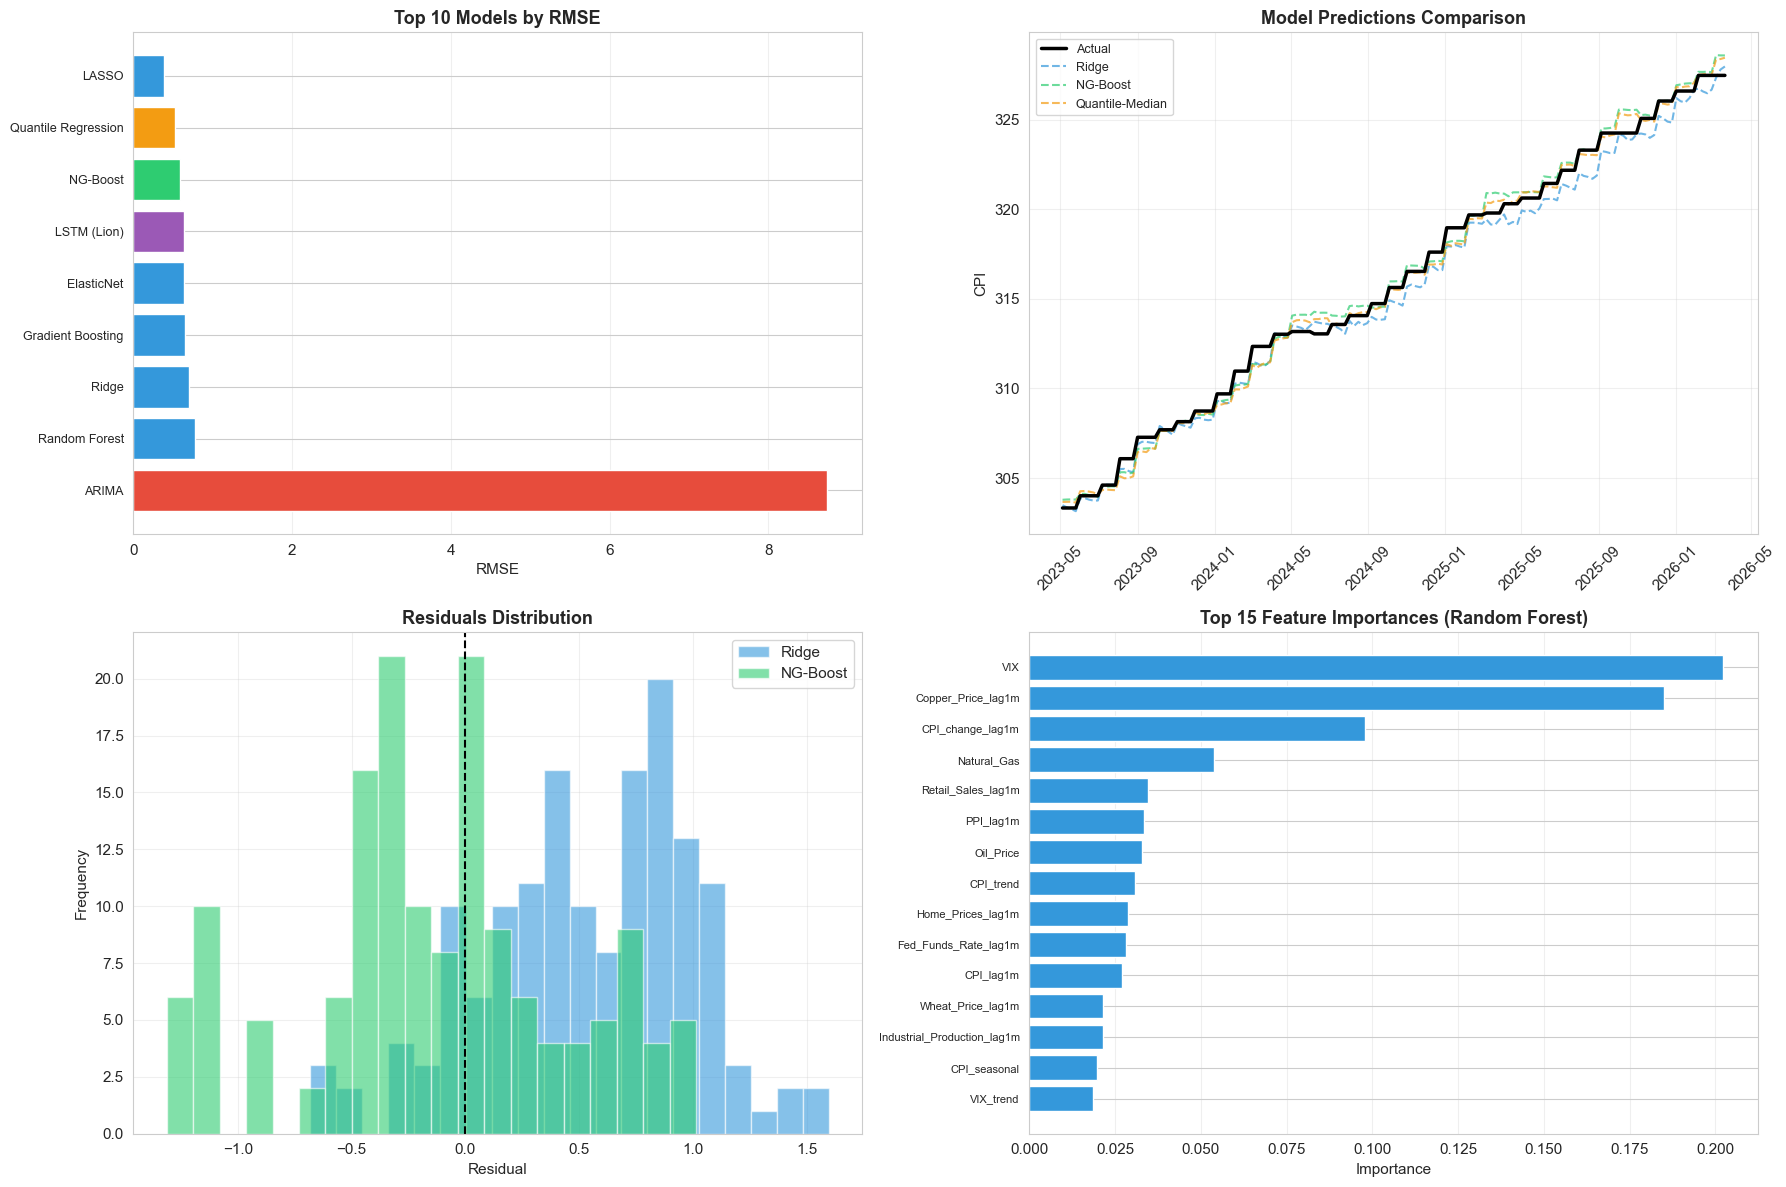

In [75]:
# Model comparison plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. RMSE comparison
top_models = results_df.head(10)
colors = {'Regression': '#3498db', 'Time Series': '#e74c3c', 
          'Probabilistic': '#2ecc71', 'Deep Learning': '#9b59b6',
          'Quantile': '#f39c12'}
bar_colors = [colors.get(cat, 'gray') for cat in top_models['Category']]

axes[0, 0].barh(range(len(top_models)), top_models['RMSE'], color=bar_colors, edgecolor='white')
axes[0, 0].set_yticks(range(len(top_models)))
axes[0, 0].set_yticklabels(top_models['Model'], fontsize=9)
axes[0, 0].set_xlabel('RMSE')
axes[0, 0].set_title('Top 10 Models by RMSE', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Predictions comparison
axes[0, 1].plot(test_data.index, y_test_level, 'k-', linewidth=2.5, label='Actual', zorder=10)
if 'Ridge' in all_models:
    axes[0, 1].plot(test_data.index, all_models['Ridge']['predictions'], 
                   '--', color='#3498db', linewidth=1.5, label='Ridge', alpha=0.7)
axes[0, 1].plot(test_data.index, ngb_level_pred, 
               '--', color='#2ecc71', linewidth=1.5, label='NG-Boost', alpha=0.7)
if 'Quantile-Median' in all_models:
    axes[0, 1].plot(test_data.index, all_models['Quantile-Median']['predictions'], 
                   '--', color='#f39c12', linewidth=1.5, label='Quantile-Median', alpha=0.7)
axes[0, 1].set_title('Model Predictions Comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('CPI')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Residuals distribution
if 'Ridge' in all_models:
    ridge_resid = y_test_level - all_models['Ridge']['predictions']
    axes[1, 0].hist(ridge_resid, bins=20, alpha=0.6, color='#3498db', label='Ridge', edgecolor='white')
ngb_resid = y_test_level - ngb_level_pred
axes[1, 0].hist(ngb_resid, bins=20, alpha=0.6, color='#2ecc71', label='NG-Boost', edgecolor='white')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature importance (Random Forest)
if 'Random Forest' in baseline_results:
    rf_model = baseline_models['Random Forest']
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[-15:]  # Top 15
    
    axes[1, 1].barh(range(len(indices)), importances[indices], color='#3498db', edgecolor='white')
    axes[1, 1].set_yticks(range(len(indices)))
    axes[1, 1].set_yticklabels([feature_cols_enhanced[i] for i in indices], fontsize=8)
    axes[1, 1].set_xlabel('Importance')
    axes[1, 1].set_title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 18. Uncertainty Quantification Comparison

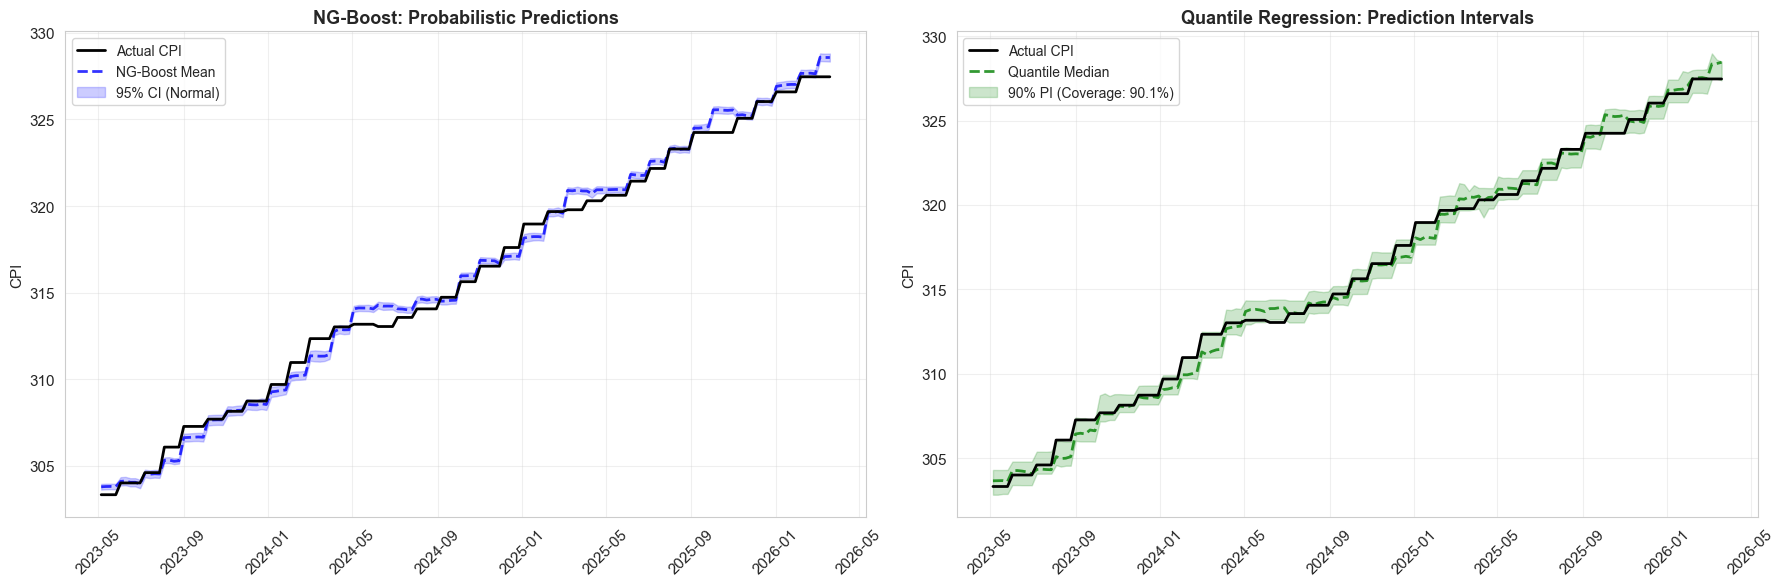


Uncertainty Quantification Metrics:
NG-Boost (95% CI):
  Average interval width: 0.4264
  Coverage (empirical):   31.79%

Quantile Regression (90% PI):
  Average interval width: 1.3456
  Coverage (empirical):   90.07%


In [76]:
# Compare uncertainty estimates from different methods
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# NG-Boost uncertainty
axes[0].plot(test_data.index, y_test_level, 'k-', linewidth=2, label='Actual CPI', zorder=5)
axes[0].plot(test_data.index, ngb_level_pred, 'b--', linewidth=2, label='NG-Boost Mean', alpha=0.8)
axes[0].fill_between(test_data.index, ngb_level_lower, ngb_level_upper, 
                     alpha=0.2, color='blue', label='95% CI (Normal)')
axes[0].set_title('NG-Boost: Probabilistic Predictions', fontsize=13, fontweight='bold')
axes[0].set_ylabel('CPI')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Quantile Regression uncertainty
axes[1].plot(test_data.index, y_test_level, 'k-', linewidth=2, label='Actual CPI', zorder=5)
axes[1].plot(test_data.index, quantile_predictions[0.50], 'g--', linewidth=2, 
            label='Quantile Median', alpha=0.8)
axes[1].fill_between(test_data.index, 
                     quantile_predictions[0.05], 
                     quantile_predictions[0.95],
                     alpha=0.2, color='green', 
                     label=f'90% PI (Coverage: {coverage:.1%})')
axes[1].set_title('Quantile Regression: Prediction Intervals', fontsize=13, fontweight='bold')
axes[1].set_ylabel('CPI')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Uncertainty metrics comparison
print("\nUncertainty Quantification Metrics:")
print("="*70)
print(f"NG-Boost (95% CI):")
print(f"  Average interval width: {np.mean(ngb_level_upper - ngb_level_lower):.4f}")
print(f"  Coverage (empirical):   {np.mean((y_test_level >= ngb_level_lower) & (y_test_level <= ngb_level_upper)):.2%}")
print(f"\nQuantile Regression (90% PI):")
print(f"  Average interval width: {interval_width:.4f}")
print(f"  Coverage (empirical):   {coverage:.2%}")

In [77]:
# Save results
results_df.to_csv('enhanced_inflation_nowcasting_results.csv', index=False)
print("\n✓ Results saved to 'enhanced_inflation_nowcasting_results.csv'")

# Save best model predictions with uncertainty
predictions_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': y_test_level,
    'Ridge': all_models.get('Ridge', {}).get('predictions', [np.nan]*len(y_test_level)),
    'NG-Boost_Mean': ngb_level_pred,
    'NG-Boost_Lower_95': ngb_level_lower,
    'NG-Boost_Upper_95': ngb_level_upper,
    'Quantile_Median': quantile_predictions[0.50],
    'Quantile_Lower_05': quantile_predictions[0.05],
    'Quantile_Upper_95': quantile_predictions[0.95],
})

predictions_df.to_csv('enhanced_inflation_predictions.csv', index=False)
print("✓ Predictions saved to 'enhanced_inflation_predictions.csv'")

# Save Diebold-Mariano test results
if dm_results:
    dm_df = pd.DataFrame(dm_results)
    dm_df.to_csv('diebold_mariano_results.csv', index=False)
    print("✓ Diebold-Mariano results saved to 'diebold_mariano_results.csv'")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)


✓ Results saved to 'enhanced_inflation_nowcasting_results.csv'
✓ Predictions saved to 'enhanced_inflation_predictions.csv'
✓ Diebold-Mariano results saved to 'diebold_mariano_results.csv'

ANALYSIS COMPLETE!
